In [20]:
pip install pandas numpy matplotlib datascience

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datascience
%matplotlib inline

In [22]:
cities = pd.read_csv("city_info-1.csv")

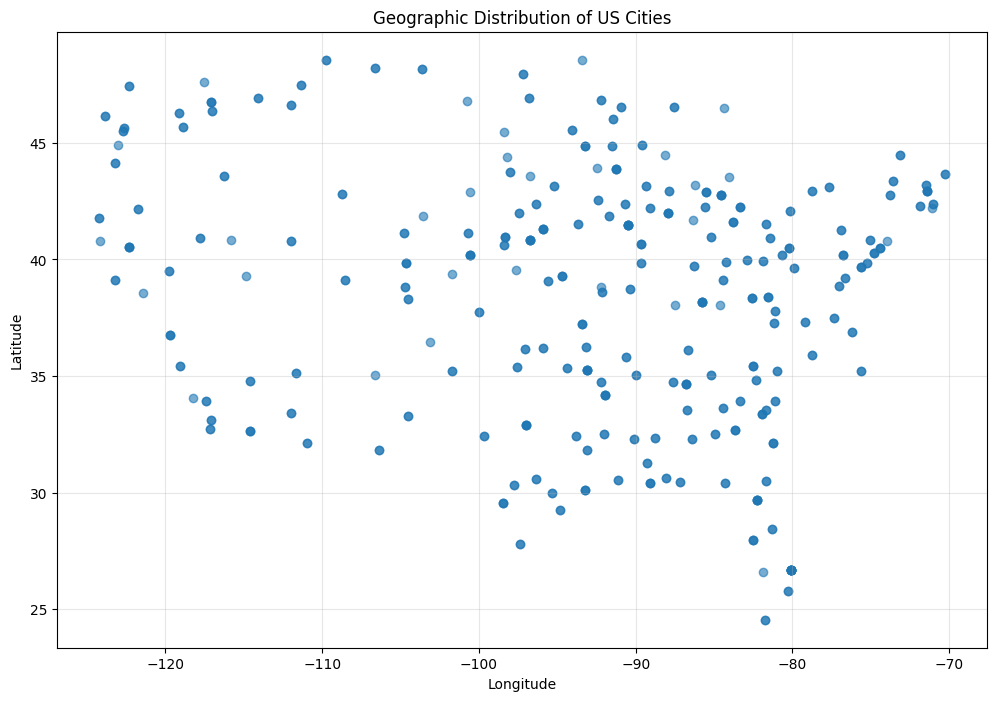

In [44]:
plt.figure(figsize=(12, 8))
plt.scatter(cities['Lon'], cities['Lat'], alpha=0.6)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of US Cities')
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
print(cities['Name'].nunique())

210


In [25]:
def coordinates_to_region(lat, lon):
    if lat >= 40 and lon >= -100:
        return "Northeast"
    elif lat >= 40 and lon < -100:
        return "Northwest"
    elif lat < 40 and lon >= -100:
        return "Southeast"
    else:
        return "Southwest"

In [26]:
cities['Region'] = cities.apply(lambda row: coordinates_to_region(row['Lat'], row['Lon']), axis=1)

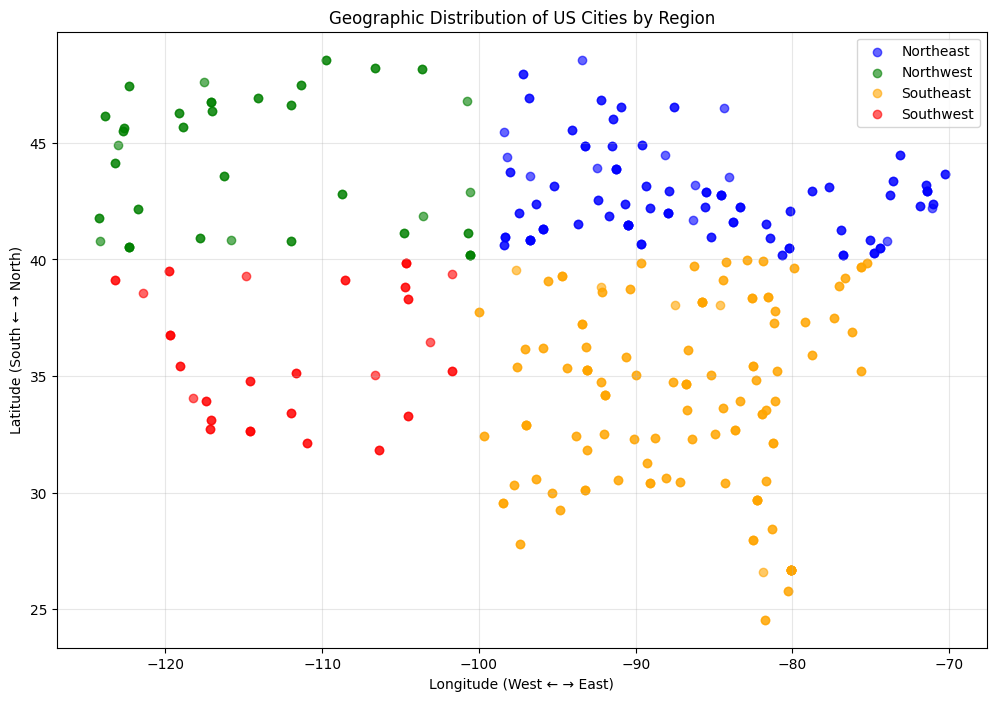

In [28]:
plt.figure(figsize=(12, 8))
regions = ['Northeast', 'Northwest', 'Southeast', 'Southwest']
colors = {
    'Northeast': 'blue',
    'Northwest': 'green',
    'Southeast': 'orange',
    'Southwest': 'red'
}
for region in regions:
    region_mask = cities['Region'] == region
    plt.scatter(cities[region_mask]['Lon'], cities[region_mask]['Lat'], 
                label=region, alpha=0.6, color=colors[region])
plt.xlabel('Longitude (West ← → East)')
plt.ylabel('Latitude (South ← → North)')
plt.title('Geographic Distribution of US Cities by Region')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
def distance(lat0, lon0, lat1, lon1):
    return np.sqrt((lat1 - lat0)**2 + (lon1 - lon0)**2)

def find_nearest_city(row):
    # Filter cities in different regions
    different_region = cities[cities['Region'] != row['Region']]
    
    if len(different_region) == 0:
        return None
    
    # Calculate distances to all cities in different regions
    distances = distance(row['Lat'], row['Lon'], 
                        different_region['Lat'].values, 
                        different_region['Lon'].values)
    
    # Find the index of the nearest city
    nearest_idx = distances.argmin()
    
    return different_region.iloc[nearest_idx]['Name']

cities_nearest = cities.copy()
cities_nearest['Nearest'] = cities_nearest.apply(find_nearest_city, axis=1)

In [31]:
phoenix = pd.read_csv("phoenix-1.csv")

In [45]:
avg_tmax = phoenix["tmax"].mean()
avg_tmin = phoenix["tmin"].mean()

highest_tmax = phoenix["tmax"].max()
highest_tmin = phoenix["tmin"].max()

print("Average maximum temperature:", round(avg_tmax))
print("Average minimum temperature:", round(avg_tmin))
print("Highest recorded maximum temperature:", round(highest_tmax))
print("Highest recorded minimum temperature:", round(highest_tmin))

Average maximum temperature: 86
Average minimum temperature: 59
Highest recorded maximum temperature: 122
Highest recorded minimum temperature: 96


In [46]:
hot_days = (phoenix["tmax"] > 110).sum()
cold_days = (phoenix["tmin"] < 32).sum()

print(hot_days)
print(cold_days)

1056
739


In [47]:
# Find date with largest daily temperature range in 2010
date_series = pd.to_datetime(phoenix["Date"])

phoenix_2010 = phoenix.loc[(date_series >= "2010-01-01") & (date_series <= "2010-12-31")].copy()
phoenix_2010["temp_range"] = phoenix_2010["tmax"] - phoenix_2010["tmin"]

largest_2010_range_date = pd.to_datetime(
    phoenix_2010.loc[phoenix_2010["temp_range"].idxmax(), "Date"]
).strftime("%Y-%m-%d")

# Temperature readings on June 24, 2010
june24_row = phoenix.loc[date_series == pd.Timestamp("2010-06-24")].iloc[0]
june24_max = june24_row["tmax"]
june24_min = june24_row["tmin"]

print(largest_2010_range_date)
print(june24_max)
print(june24_min)

2010-06-24
113.0
79.0


In [36]:
phoenix["Year"] = date_series.dt.year.astype(int)
phoenix["Month"] = date_series.dt.strftime("%m (%b)")


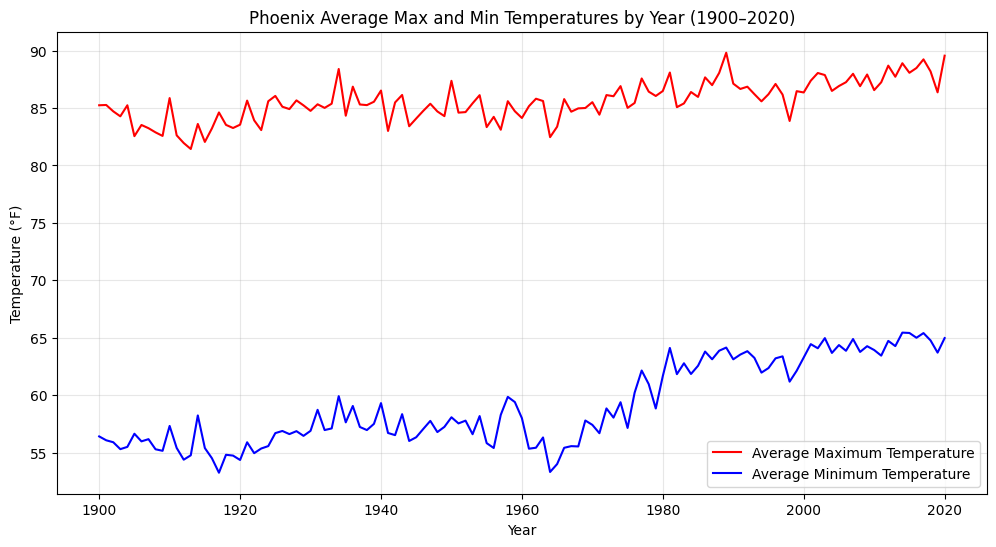

In [37]:
yearly_temps = (
    phoenix.loc[(phoenix["Year"] >= 1900) & (phoenix["Year"] <= 2020)]
    .groupby("Year")[["tmax", "tmin"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(yearly_temps["Year"], yearly_temps["tmax"], label="Average Maximum Temperature", color="red")
plt.plot(yearly_temps["Year"], yearly_temps["tmin"], label="Average Minimum Temperature", color="blue")

plt.xlabel("Year")
plt.ylabel("Temperature (°F)")
plt.title("Phoenix Average Max and Min Temperatures by Year (1900–2020)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
phoenix_with_period = phoenix.copy()

def return_period(year):
    if 1900 <= year <= 1960:
        return "Past"
    elif 2019 <= year <= 2021:
        return "Present"
    return np.nan

phoenix_with_period["Period"] = phoenix_with_period["Year"].apply(return_period)

# Build monthly_increases table
monthly_increases = (
    phoenix_with_period.dropna(subset=["Period"]).groupby(["Month", "Period"])["tmax"].mean().unstack().reset_index().rename_axis(None, axis=1)
)

monthly_increases["Increase"] = monthly_increases["Present"] - monthly_increases["Past"]
monthly_increases = monthly_increases[["Month", "Past", "Present", "Increase"]].sort_values("Month").reset_index(drop=True)

print(monthly_increases)

       Month        Past     Present  Increase
0   01 (Jan)   65.016393   67.831183  2.814789
1   02 (Feb)   68.848520   69.185882  0.337362
2   03 (Mar)   74.649921   75.979570  1.329649
3   04 (Apr)   82.642077   88.400000  5.757923
4   05 (May)   91.429931   94.570968  3.141036
5   06 (Jun)  101.166120  105.734444  4.568324
6   07 (Jul)  103.598625  107.245161  3.646536
7   08 (Aug)  101.416182  107.383871  5.967689
8   09 (Sep)   97.687432  101.237778  3.550346
9   10 (Oct)   86.797990   90.166667  3.368676
10  11 (Nov)   74.627322   80.517778  5.890455
11  12 (Dec)   65.906399   67.454839  1.548440
